In [63]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Force the process to use GPU #1

cache_dir = "/a/home/cc/students/cs/adihaviv1/dcor_dir/cache"

# Set HuggingFace cache locations
os.environ["HF_HOME"] = cache_dir
os.environ["TRANSFORMERS_CACHE"] = cache_dir
os.environ["HF_DATASETS_CACHE"] = cache_dir

import torch
from PIL import Image
from tqdm.auto import tqdm

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    LlavaForConditionalGeneration,
    StoppingCriteria,
    StoppingCriteriaList,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

In [2]:
# import staff
import sys

# Uncomment if use clonned version of TransformerLens
# currently forked version https://github.com/zazamrykh/TransformerLens supports
TL_path = r"../"
if TL_path not in sys.path:
	sys.path.insert(0, TL_path)
	sys.path.insert(0, TL_path + r"/transformer_lens")


from activation_utils import load_model

model_name = "llava"
model_path = "llava-hf/llava-1.5-7b-hf"

print("Loading processor...")
processor = AutoProcessor.from_pretrained(
    model_path,
    cache_dir=cache_dir
)

print("Loading model...")
with tqdm(total=1, desc="Loading LLaVA model") as pbar:
    model = LlavaForConditionalGeneration.from_pretrained(
    #model = load_model(
    #    model_path,
        model_path,
        cache_dir=cache_dir,  # <--- YOUR CACHE DIR
        #device=device,
        torch_dtype=torch.float16,
        attn_implementation="eager",   # critical for returning attentions
        device_map="cuda",
    )
    pbar.update(1)

model = model.to(device)
print("Model loaded on:", device)
model.eval()

Loading processor...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading model...


Loading LLaVA model:   0%|          | 0/1 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded on: cuda:0


LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
       

In [3]:
class TqdmGenerationTracker(StoppingCriteria):
    def __init__(self, pbar):
        super().__init__()
        self.pbar = pbar

    def __call__(self, input_ids, scores, **kwargs):
        self.pbar.update(1)
        return False  # never stop early


def llava_answer(image_path, question, max_new_tokens=128):
    print(f"Loading image: {image_path}")
    image = Image.open(image_path).convert("RGB")

    prompt = f"USER: <image>\n{question}\nASSISTANT:"

    print("Processing inputs...")
    with tqdm(total=1, desc="Preprocessing") as pbar:
        inputs = processor(
            text=prompt,
            images=image,
            return_tensors="pt"
        ).to(device)
        pbar.update(1)

    print("Generating answer...")
    gen_pbar = tqdm(total=max_new_tokens, desc="Generating tokens")
    stopping = StoppingCriteriaList([TqdmGenerationTracker(gen_pbar)])

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            stopping_criteria=stopping
        )

    gen_pbar.close()

    # Decode only newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0][input_len:]

    return processor.tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )


def llava_answer_from_image(image, question, max_new_tokens=128):
    """
    image: PIL.Image.Image (already loaded)
    question: str
    """
    # Ensure RGB
    if not isinstance(image, Image.Image):
        raise TypeError("image must be a PIL.Image.Image object")
    image = image.convert("RGB")

    prompt = f"USER: <image>\n{question}\nASSISTANT:"

    print("Processing inputs...")
    with tqdm(total=1, desc="Preprocessing") as pbar:
        inputs = processor(
            text=prompt,
            images=image,
            return_tensors="pt"
        ).to(device)
        pbar.update(1)

    print("Generating answer...")
    gen_pbar = tqdm(total=max_new_tokens, desc="Generating tokens")
    stopping = StoppingCriteriaList([TqdmGenerationTracker(gen_pbar)])

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            stopping_criteria=stopping
        )

    gen_pbar.close()

    # Decode only newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0][input_len:]

    return processor.tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )



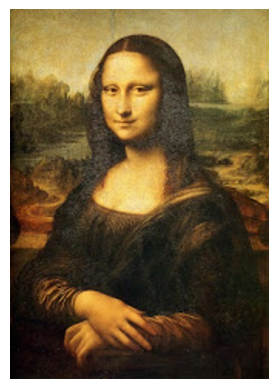

In [4]:
import sys
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

image_url = "https://www.dropbox.com/scl/fi/5lyldb9vfk58m4e18g0iq/Mona-Lisa.jpg?rlkey=igcuofxang00z6ok86xc8dxgf&st=lmcdpzz2&dl=1"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
plt.axis('off')
_ = plt.imshow(image)

In [5]:

question = "What do you see in this image?"
answer = llava_answer_from_image(image, question, max_new_tokens=100)
print(answer)

Processing inputs...


Preprocessing:   0%|          | 0/1 [00:00<?, ?it/s]

Generating answer...


Generating tokens:   0%|          | 0/100 [00:00<?, ?it/s]

The image features a painting of a woman, possibly a portrait of Leonardo da Vinci's famous Mona Lisa. The woman is wearing a long dress and is looking directly at the viewer. The painting is displayed in a frame, which adds to the artistic presentation.

In the background, there is a boat visible, possibly indicating a connection to the famous painting of the Mona Lisa, which is said to have been painted during a time when the artist was living in


In [6]:
from PIL import Image

#image = Image.open(image_path).convert("RGB")
question = "how many hands are in the image?"

prompt = f"USER: <image>\n{question}\nASSISTANT:"
inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

with torch.no_grad():
    out = model(
        **inputs,
        output_attentions=True,
        use_cache=False,      # keeps shapes straightforward
        return_dict=True,
    )

attentions = out.attentions  # tuple: length = num_layers
# each element: (batch, num_heads, seq_len, seq_len)

answer = llava_answer_from_image(image, question, max_new_tokens=100)
print(answer)

Processing inputs...


Preprocessing:   0%|          | 0/1 [00:00<?, ?it/s]

Generating answer...


Generating tokens:   0%|          | 0/100 [00:00<?, ?it/s]

There are two hands in the image.


In [7]:
import torch

image_token_id = model.config.image_token_index
input_ids = inputs["input_ids"][0]  # (seq_len,)

img_pos = (input_ids == image_token_id).nonzero(as_tuple=True)[0]  # positions of image tokens
txt_pos = (input_ids != image_token_id).nonzero(as_tuple=True)[0]  # all non-image tokens


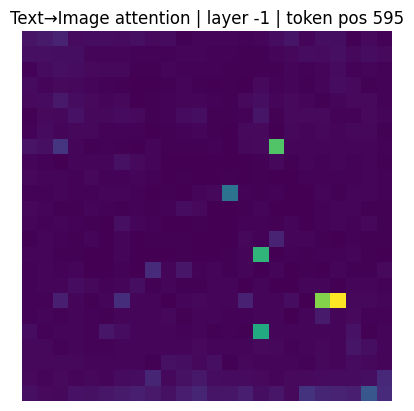

In [8]:
import math
import matplotlib.pyplot as plt

layer = -1
A = attentions[layer][0]  # (heads, seq, seq)

query_token_pos = int(txt_pos[-1])  # pick last non-image token as the query
text_to_image = A[:, query_token_pos, img_pos]  # (heads, num_img_tokens)

# average over heads
text_to_image_mean = text_to_image.mean(dim=0)  # (num_img_tokens,)

# reshape to a grid (often 24x24=576, but check)
n = text_to_image_mean.numel()
s = int(math.sqrt(n))
if s * s != n:
    print("Image token count is not a perfect square:", n)
else:
    heat = text_to_image_mean.reshape(s, s).float().cpu().numpy()
    plt.figure()
    plt.imshow(heat)
    plt.title(f"Text→Image attention | layer {layer} | token pos {query_token_pos}")
    plt.axis("off")
    plt.show()


In [9]:
gen = model.generate(
    **inputs,
    max_new_tokens=30,
    return_dict_in_generate=True,
    output_attentions=True,
)
# gen.attentions is a nested structure across generation steps


In [70]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def _normalize01(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + eps)

def llava_text_to_image_attention_overlay_grid(
    model,
    processor,
    image,                   # PIL.Image
    prompt_text,
    query_token_pos=None,    # if None: last non-image token
    layer_indices=None,      # if None: all layers
    head_reduce="mean",      # must be "mean" for overlay
    alpha=0.45,              # overlay transparency
    cmap="jet",              # heatmap colormap
    plot=True,
):
    """
    Produces per-layer text->image attention maps and overlays them on the image.
    Displays results in one n×n grid (side-by-side), NO colorbar.

    Returns:
      overlays: dict[layer_idx] -> (H, W, 3) float image (0..1) of overlay heat
      heatmaps: dict[layer_idx] -> (s, s) attention grid (0..1 normalized)
      meta: dict with positions, shapes
    """
    if not isinstance(image, Image.Image):
        raise TypeError("image must be a PIL.Image.Image")

    model.eval()

    # Keep a numpy version of the original image for plotting
    img_rgb = image.convert("RGB")
    img_np = np.asarray(img_rgb).astype(np.float32) / 255.0
    H, W = img_np.shape[:2]

    inputs = processor(text=prompt_text, images=img_rgb, return_tensors="pt").to(model.device)
    input_ids = inputs["input_ids"][0]

    image_token_id = model.config.image_token_index
    img_pos = (input_ids == image_token_id).nonzero(as_tuple=True)[0]
    txt_pos = (input_ids != image_token_id).nonzero(as_tuple=True)[0]

    if img_pos.numel() == 0:
        raise ValueError("No image tokens found. Ensure prompt contains <image>.")

    if query_token_pos is None:
        query_token_pos = int(txt_pos[-1])

    with torch.no_grad():
        out = model(
            **inputs,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

    attentions = out.attentions
    num_layers = len(attentions)
    if layer_indices is None:
        layer_indices = list(range(num_layers))

    if head_reduce != "mean":
        raise ValueError("For overlay visualization, set head_reduce='mean'.")

    # Reshape image-token vector to square patch grid
    n_img = img_pos.numel()
    s = int(math.sqrt(n_img))
    can_square_reshape = (s * s == n_img)
    if not can_square_reshape:
        raise ValueError(
            f"{n_img} image tokens cannot be reshaped into a square grid. "
            "Overlay requires a square patch grid."
        )

    heatmaps = {}
    overlays = {}

    # Collect heatmaps first (for consistent normalization if desired)
    layer_list = []
    for li in layer_indices:
        A = attentions[li][0]                 # (heads, seq, seq)
        v = A[:, query_token_pos, img_pos]    # (heads, n_img)
        v = v.mean(dim=0)                     # (n_img,)
        hm = v.reshape(s, s).float().cpu().numpy()
        heatmaps[li] = hm
        layer_list.append(li)

    # Normalize each layer heatmap to 0..1 (layer-wise)
    for li in layer_list:
        hm01 = _normalize01(heatmaps[li])

        # Upsample patch-grid heatmap to image pixels
        # Using matplotlib's imshow interpolation for upsampling inside overlay plot is fine,
        # but we’ll explicitly make a resized heatmap via PIL for control.
        hm_img = Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.BILINEAR)
        hm_up = np.asarray(hm_img).astype(np.float32) / 255.0  # (H, W) in 0..1

        overlays[li] = hm_up  # store 2D; we overlay during plotting

    # ---- Plot: n×n grid of overlays (no colorbar) ----
    if plot:
        n = len(layer_list)
        grid = math.ceil(math.sqrt(n))
        fig, axes = plt.subplots(grid, grid, figsize=(3.2 * grid, 3.2 * grid))
        axes = np.array(axes).reshape(-1)

        for ax, li in zip(axes, layer_list):
            ax.imshow(img_np)  # base image
            ax.imshow(overlays[li], cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)  # overlay heat
            ax.set_title(f"Layer {li}")
            ax.axis("off")

        for ax in axes[len(layer_list):]:
            ax.axis("off")

        fig.suptitle(f"Text→Image attention overlay (token pos {query_token_pos})", fontsize=14)
        plt.tight_layout()
        plt.show()

    meta = {
        "query_token_pos": query_token_pos,
        "n_layers": num_layers,
        "n_img_tokens": int(n_img),
        "square_grid_size": s,
        "img_positions": img_pos.detach().cpu().tolist(),
        "txt_positions": txt_pos.detach().cpu().tolist(),
        "overlay_alpha": alpha,
        "overlay_cmap": cmap,
    }

    return overlays, heatmaps, meta


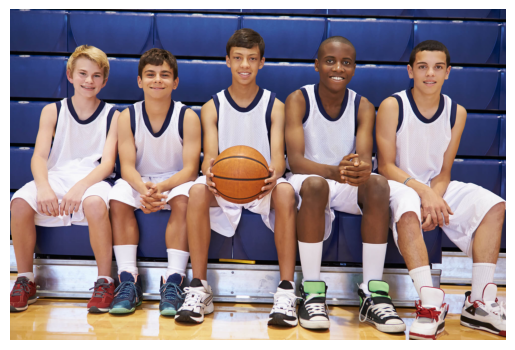

In [71]:
from PIL import Image
image_path = "/home/dcor/adihaviv1/start/ICLR_DATA/sport/original/sport_3.jpg"
#image_path = "/home/dcor/adihaviv1/start/ICLR_DATA/artwork/generic/v2_2/beatles_crop.jpg"
image = Image.open(image_path).convert("RGB")

plt.axis('off')
_ = plt.imshow(image)

Processing inputs...


Preprocessing:   0%|          | 0/1 [00:00<?, ?it/s]

Generating answer...


Generating tokens:   0%|          | 0/100 [00:00<?, ?it/s]

Yes, there is a basketball in the image.


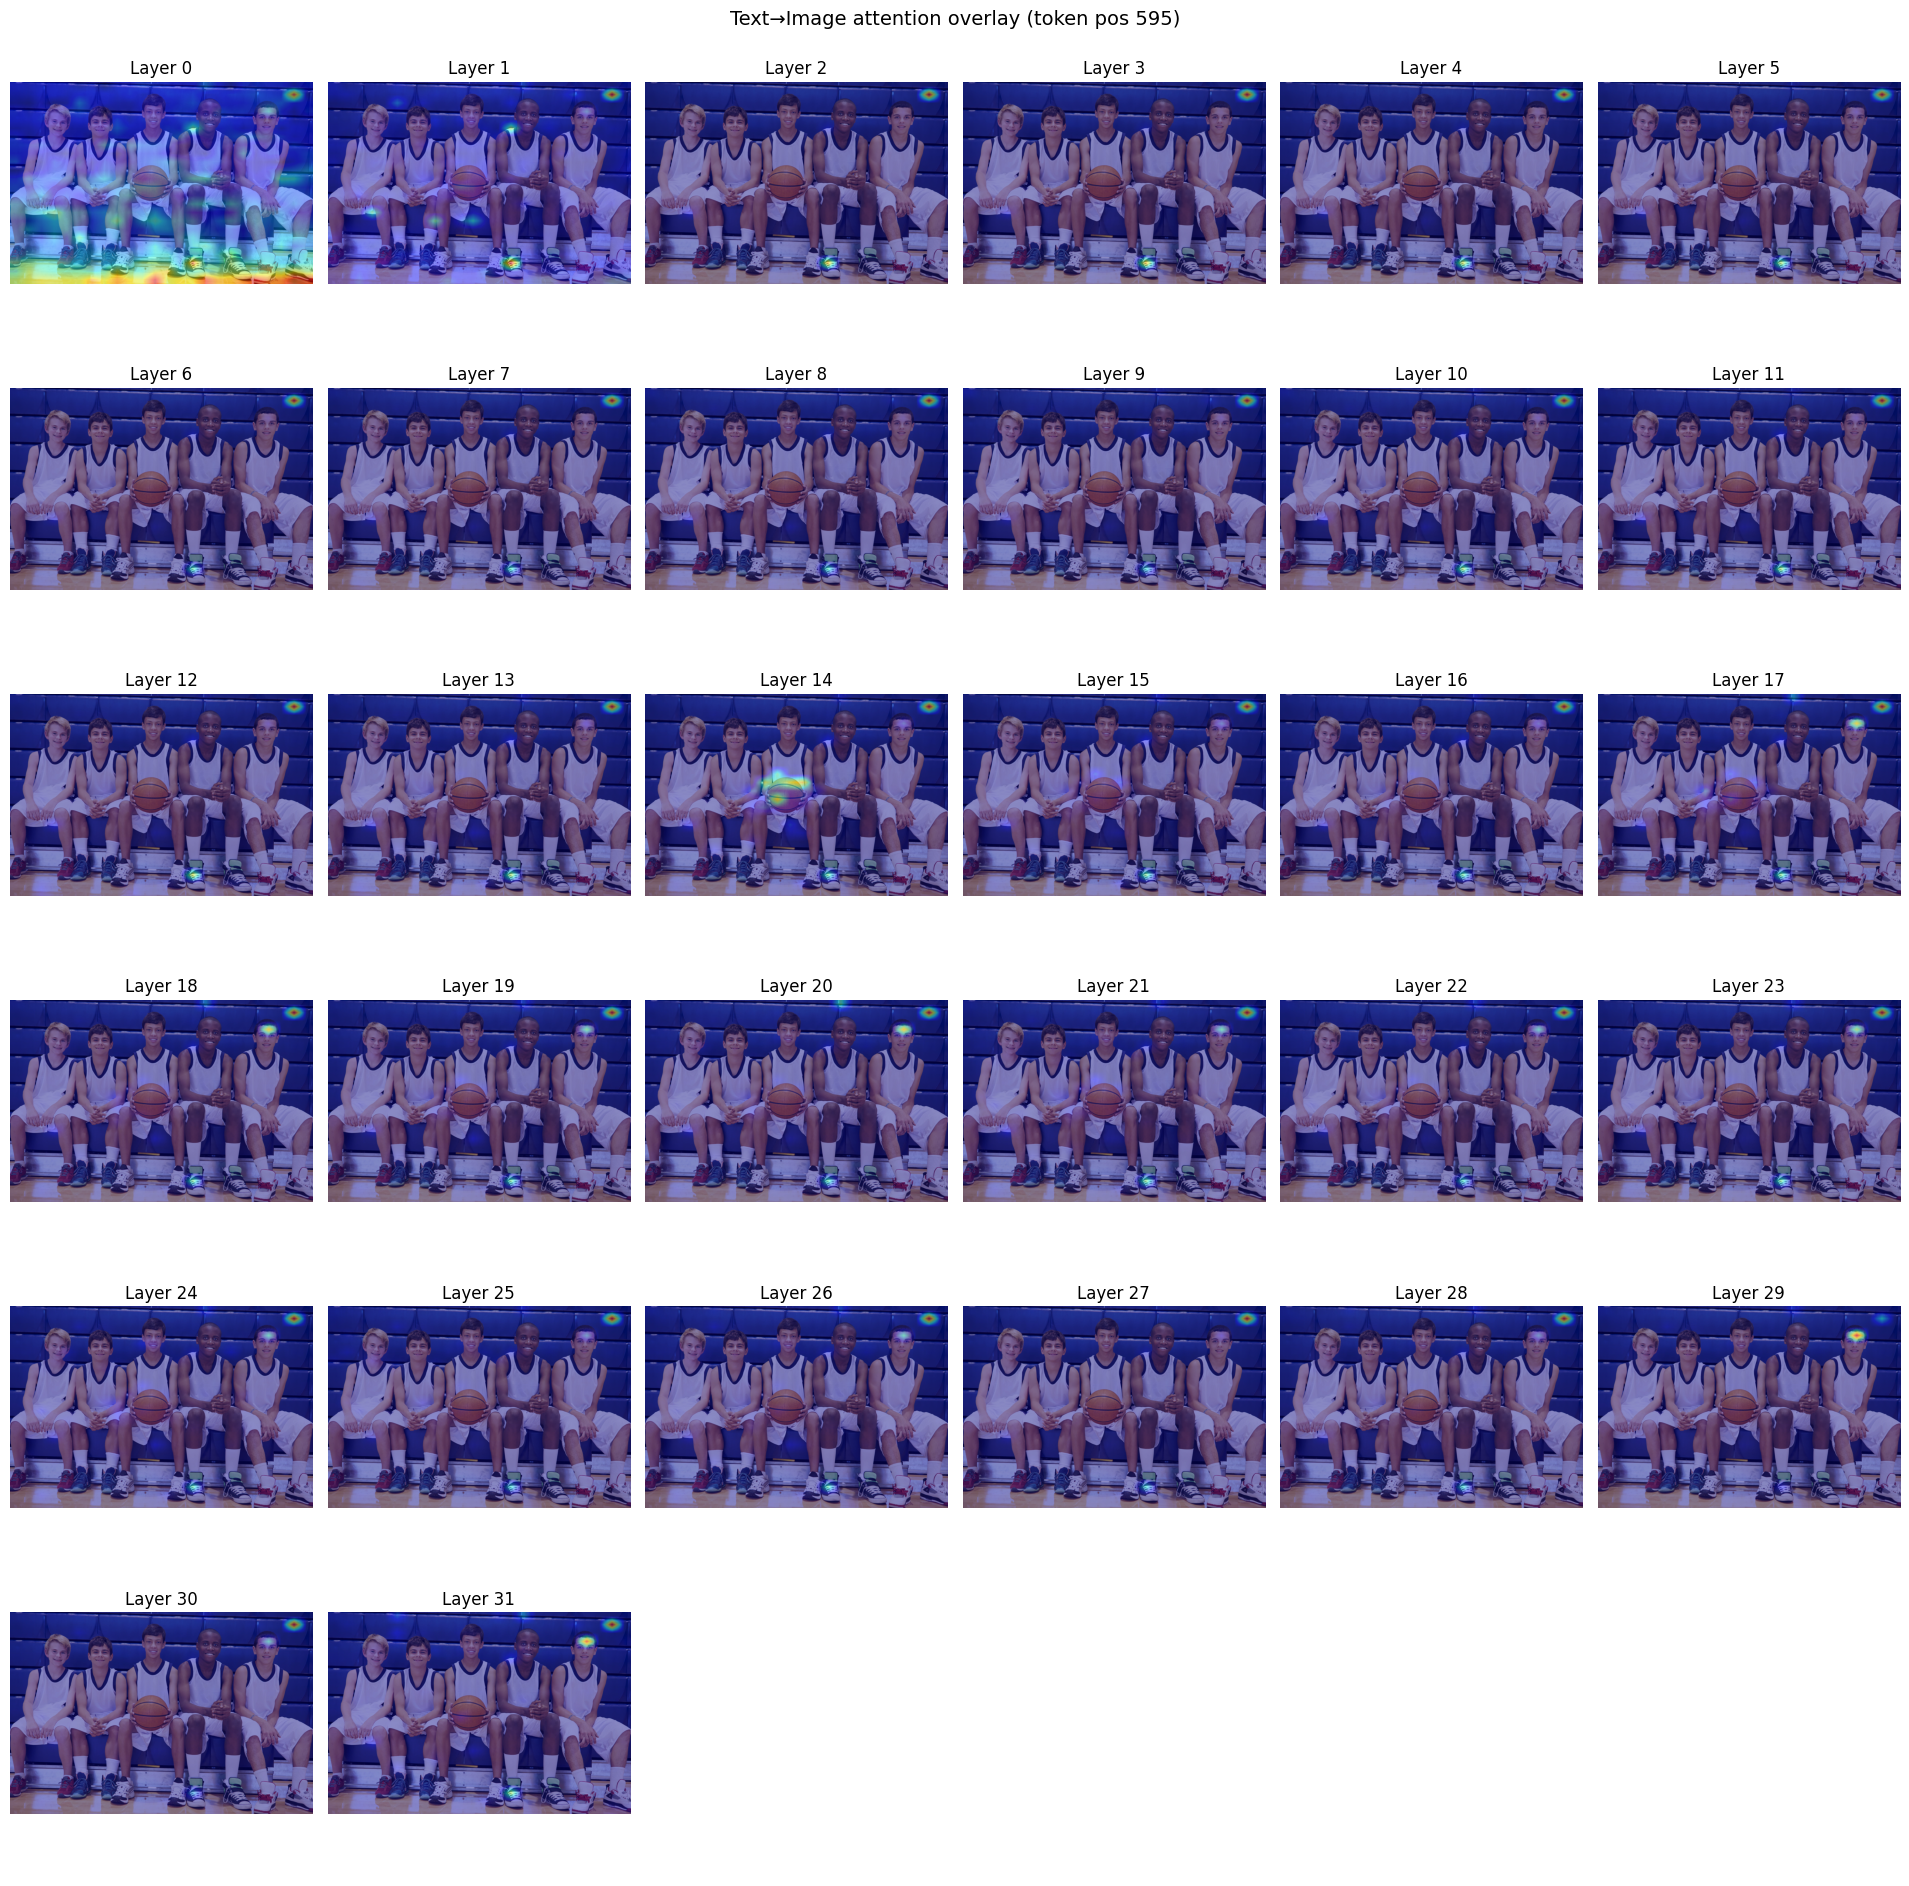

In [73]:
question = "is there a ball in the image??"
prompt = f"USER: <image>\n{question}\nASSISTANT:"

answer = llava_answer_from_image(image, question, max_new_tokens=100)
print(answer)

overlays, heatmaps, meta = llava_text_to_image_attention_overlay_grid(
    model=model,
    processor=processor,
    image=image,               # PIL image object
    prompt_text=prompt,
    layer_indices=None,        # all layers
    alpha=0.45,
    cmap="jet",
    plot=True,

    
)



In [1]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
import requests
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm
cache_dir = "/a/home/cc/students/cs/adihaviv1/dcor_dir/cache"
model_id = "llava-hf/llava-1.5-7b-hf"  # change if you use a different llava-hf repo

device = torch.device("cuda:0")  # because CUDA_VISIBLE_DEVICES="1"

processor = AutoProcessor.from_pretrained(model_id, cache_dir=cache_dir)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    cache_dir=cache_dir,
).to(device)
model.eval()

def load_image_from_url(url: str) -> Image.Image:
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

#image_url = "https://www.dropbox.com/scl/fi/5lyldb9vfk58m4e18g0iq/Mona-Lisa.jpg?rlkey=igcuofxang00z6ok86xc8dxgf&st=lmcdpzz2&dl=1"
#image = load_image_from_url(image_url)
#image



/home/dcor/adihaviv1/miniconda3/envs/llava_attn1/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [2]:

image_path = "/home/dcor/adihaviv1/start/ICLR_DATA/sport/original/sport_3.jpg"
#image_path = "/home/dcor/adihaviv1/start/ICLR_DATA/artwork/generic/v2_2/beatles_crop.jpg"
image = Image.open(image_path).convert("RGB")

In [8]:
import torch.nn as nn

def find_transformer_layers(model):
    """
    Find a ModuleList of transformer blocks by scanning the module tree.
    A transformer block is identified by having attribute 'self_attn'.

    Returns:
        (path_str, layers_modulelist)
    """
    best = None  # (path, modulelist)

    for name, module in model.named_modules():
        if isinstance(module, nn.ModuleList) and len(module) > 0:
            # Heuristic: modulelist elements should have self_attn
            first = module[0]
            if hasattr(first, "self_attn"):
                # Prefer the one that looks like the core stack (many layers)
                if best is None or len(module) > len(best[1]):
                    best = (name, module)

    if best is None:
        raise AttributeError("Could not find a ModuleList of transformer layers with .self_attn")

    path, layers = best
    print(f"[OK] Found transformer layers at: {path} (n_layers={len(layers)})")
    print(f"     Example layer type: {type(layers[0]).__name__}")
    return path, layers


In [9]:
layers_path, layers = find_transformer_layers(model)


[OK] Found transformer layers at: model.language_model.layers (n_layers=32)
     Example layer type: LlamaDecoderLayer


In [10]:
import torch
import torch.nn as nn
from contextlib import contextmanager

def find_transformer_layers(model):
    """
    Find a ModuleList of transformer blocks by scanning the module tree.
    Identifies blocks by presence of .self_attn on first element.
    """
    best = None  # (path, modulelist)

    for name, module in model.named_modules():
        if isinstance(module, nn.ModuleList) and len(module) > 0:
            if hasattr(module[0], "self_attn"):
                if best is None or len(module) > len(best[1]):
                    best = (name, module)

    if best is None:
        raise AttributeError("Could not find transformer layers (ModuleList with .self_attn).")

    path, layers = best
    print(f"[OK] Found transformer layers at: {path} (n_layers={len(layers)})")
    return path, layers

def _modify_attn_output(attn_out: torch.Tensor, mode: str) -> torch.Tensor:
    # attn_out: (batch, seq_len, hidden)
    if mode == "zero":
        return torch.zeros_like(attn_out)
    elif mode == "mean_ablation":
        mu = attn_out.mean(dim=1, keepdim=True)  # mean over tokens
        return mu.expand_as(attn_out)
    else:
        raise ValueError(f"Unknown mode: {mode}")

@contextmanager
def knockout_layers_attention_outputs(model, layer_ids=(14, 15), mode="zero"):
    """
    Hooks self-attention outputs for the specified transformer block indices.
    """
    _, layers = find_transformer_layers(model)
    handles = []

    for li in layer_ids:
        if li < 0 or li >= len(layers):
            raise IndexError(f"Layer index {li} out of range (n_layers={len(layers)})")

        block = layers[li]
        if not hasattr(block, "self_attn"):
            raise AttributeError(f"Layer {li} has no .self_attn")

        attn_mod = block.self_attn

        def hook_fn(module, inp, out, _mode=mode):
            # out may be tensor or tuple (attn_out, attn_weights, past_kv)
            if isinstance(out, tuple):
                attn_out = out[0]
                attn_out = _modify_attn_output(attn_out, _mode)
                return (attn_out,) + out[1:]
            return _modify_attn_output(out, _mode)

        handles.append(attn_mod.register_forward_hook(hook_fn))

    try:
        yield
    finally:
        for h in handles:
            h.remove()


In [11]:
def llava_generate(image: Image.Image, question: str, max_new_tokens: int = 128) -> str:
    prompt = f"USER: <image>\n{question}\nASSISTANT:"
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        # tqdm here tracks "requests" not tokens (token-level progress needs a stopping-criteria hack)
        for _ in tqdm(range(1), desc="generate", leave=False):
            out_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )

    # Decode only newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    gen_ids = out_ids[0, input_len:]
    return processor.tokenizer.decode(gen_ids, skip_special_tokens=True).strip()


In [12]:
def run_knockout_experiment(image: Image.Image):
    # Pick something that is plausibly checkable.
    # For Mona Lisa, use a prompt that injects wrong info and see if the model copies it.
    baseline_q   = "is there a ball in the image?"
    misaligned_q = "is there a dog in the image?"  # intentionally wrong

    print("=== BASELINE (no mismatch) ===")
    print("Q:", baseline_q)

    print("\n--- No knockout ---")
    ans0 = llava_generate(image, baseline_q)
    print(ans0)

    print("\n--- Knockout layers 14&15: ZERO ---")
    with knockout_layers_attention_outputs(model, layer_ids=(14, 15), mode="zero"):
        ans1 = llava_generate(image, baseline_q)
    print(ans1)

    print("\n--- Knockout layers 14&15: MEAN-ABLATION ---")
    with knockout_layers_attention_outputs(model, layer_ids=(14, 15), mode="mean_ablation"):
        ans2 = llava_generate(image, baseline_q)
    print(ans2)

    print("\n\n=== MISALIGNED PROMPT (prompt-induced hallucination test) ===")
    print("Q:", misaligned_q)

    print("\n--- No knockout ---")
    ans0m = llava_generate(image, misaligned_q)
    print(ans0m)

    print("\n--- Knockout layers 14&15: ZERO ---")
    with knockout_layers_attention_outputs(model, layer_ids=(14, 15), mode="zero"):
        ans1m = llava_generate(image, misaligned_q)
    print(ans1m)

    print("\n--- Knockout layers 14&15: MEAN-ABLATION ---")
    with knockout_layers_attention_outputs(model, layer_ids=(14, 15), mode="mean_ablation"):
        ans2m = llava_generate(image, misaligned_q)
    print(ans2m)

run_knockout_experiment(image)


=== BASELINE (no mismatch) ===
Q: is there a ball in the image?

--- No knockout ---


generate:   0%|          | 0/1 [00:00<?, ?it/s]

Yes, there is a basketball in the image.

--- Knockout layers 14&15: ZERO ---
[OK] Found transformer layers at: model.language_model.layers (n_layers=32)
     Example layer type: LlamaDecoderLayer


generate:   0%|          | 0/1 [00:00<?, ?it/s]

Yes, there is a ball in the image. The young men are sitting on a bench, and the ball is placed in front of them.

--- Knockout layers 14&15: MEAN-ABLATION ---
[OK] Found transformer layers at: model.language_model.layers (n_layers=32)
     Example layer type: LlamaDecoderLayer


...

No, there is no dog in the image. The image features a group of young men sitting on a bench, posing with a basketball.

--- Knockout layers 14&15: ZERO ---
[OK] Found transformer layers at: model.language_model.layers (n_layers=32)
     Example layer type: LlamaDecoderLayer


generate:   0%|          | 0/1 [00:00<?, ?it/s]

No, there is no dog in the image. The image features a group of young men sitting on a bench, posing with a basketball.

--- Knockout layers 14&15: MEAN-ABLATION ---
[OK] Found transformer layers at: model.language_model.layers (n_layers=32)
     Example layer type: LlamaDecoderLayer


generate:   0%|          | 0/1 [00:00<?, ?it/s]

No, there is no dog in the image. The image features a group of young men sitting on a bench, holding a basketball.


In [15]:
def llava_generate_from_image(image, question, max_new_tokens=80):
    prompt = f"USER: <image>\n{question}\nASSISTANT:"
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    gen_ids = out_ids[0, input_len:]
    return processor.tokenizer.decode(gen_ids, skip_special_tokens=True).strip(), prompt


In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def _normalize01(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + eps)

def llava_text_to_image_attention_overlay_grid(
    model,
    processor,
    image,                   # PIL.Image
    prompt_text,
    query_token_pos=None,    # if None: last non-image token
    layer_indices=None,      # if None: all layers
    alpha=0.45,              # overlay transparency
    cmap="jet",
    plot=True,
):
    if not isinstance(image, Image.Image):
        raise TypeError("image must be a PIL.Image.Image")

    model.eval()

    img_rgb = image.convert("RGB")
    img_np = np.asarray(img_rgb).astype(np.float32) / 255.0
    H, W = img_np.shape[:2]

    inputs = processor(text=prompt_text, images=img_rgb, return_tensors="pt").to(model.device)
    input_ids = inputs["input_ids"][0]

    image_token_id = model.config.image_token_index
    img_pos = (input_ids == image_token_id).nonzero(as_tuple=True)[0]
    txt_pos = (input_ids != image_token_id).nonzero(as_tuple=True)[0]

    if img_pos.numel() == 0:
        raise ValueError("No image tokens found. Ensure prompt contains <image>.")

    if query_token_pos is None:
        query_token_pos = int(txt_pos[-1])  # last prompt token (non-image)

    with torch.no_grad():
        out = model(
            **inputs,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

    attentions = out.attentions
    num_layers = len(attentions)
    if layer_indices is None:
        layer_indices = list(range(num_layers))

    # image token grid
    n_img = img_pos.numel()
    s = int(math.sqrt(n_img))
    if s * s != n_img:
        raise ValueError(f"{n_img} image tokens cannot be reshaped into a square grid.")

    heatmaps = {}
    overlays = {}

    layer_list = []
    for li in layer_indices:
        A = attentions[li][0]              # (heads, seq, seq) for batch 0
        v = A[:, query_token_pos, img_pos] # (heads, n_img)
        v = v.mean(dim=0)                  # avg over heads
        hm = v.reshape(s, s).float().cpu().numpy()
        heatmaps[li] = hm
        layer_list.append(li)

    for li in layer_list:
        hm01 = _normalize01(heatmaps[li])
        hm_img = Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.BILINEAR)
        overlays[li] = np.asarray(hm_img).astype(np.float32) / 255.0

    if plot:
        plt.close("all")  # prevent any lingering colorbar from prior figs

        n = len(layer_list)
        grid = math.ceil(math.sqrt(n))
        fig, axes = plt.subplots(grid, grid, figsize=(3.2 * grid, 3.2 * grid), constrained_layout=True)
        axes = np.array(axes).reshape(-1)

        for ax, li in zip(axes, layer_list):
            ax.imshow(img_np)
            ax.imshow(overlays[li], cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
            ax.set_title(f"Layer {li}")
            ax.axis("off")

        for ax in axes[len(layer_list):]:
            ax.axis("off")

        fig.suptitle(f"Text→Image attention overlay (prompt token pos {query_token_pos})", fontsize=14)
        plt.show()

    meta = {
        "query_token_pos": query_token_pos,
        "n_layers": num_layers,
        "n_img_tokens": int(n_img),
        "square_grid_size": s,
        "img_positions": img_pos.detach().cpu().tolist(),
        "txt_positions": txt_pos.detach().cpu().tolist(),
    }
    return overlays, heatmaps, meta


In [17]:
def run_knockout_with_overlays(
    image,
    question,
    knockout_layers=(14, 15),
    viz_layers=None,          # e.g., range(10, 20) or None for all
    max_new_tokens=80,
    alpha=0.45,
    cmap="jet",
):
    # --- Baseline ---
    print("\n================ BASELINE (no knockout) ================")
    ans_base, prompt = llava_generate_from_image(image, question, max_new_tokens=max_new_tokens)
    print("Q:", question)
    print("A:", ans_base)

    print("\n[Overlay] BASELINE")
    llava_text_to_image_attention_overlay_grid(
        model=model,
        processor=processor,
        image=image,
        prompt_text=prompt,
        layer_indices=list(viz_layers) if viz_layers is not None else None,
        alpha=alpha,
        cmap=cmap,
        plot=True,
    )

    # --- Knockout ZERO ---
    print("\n================ KNOCKOUT: ZERO (layers {}) ================".format(knockout_layers))
    with knockout_layers_attention_outputs(model, layer_ids=knockout_layers, mode="zero"):
        ans_zero, prompt_zero = llava_generate_from_image(image, question, max_new_tokens=max_new_tokens)
        print("A:", ans_zero)

        print("\n[Overlay] ZERO knockout")
        llava_text_to_image_attention_overlay_grid(
            model=model,
            processor=processor,
            image=image,
            prompt_text=prompt_zero,
            layer_indices=list(viz_layers) if viz_layers is not None else None,
            alpha=alpha,
            cmap=cmap,
            plot=True,
        )

    # --- Knockout MEAN-ABLATION ---
    print("\n================ KNOCKOUT: MEAN-ABLATION (layers {}) ================".format(knockout_layers))
    with knockout_layers_attention_outputs(model, layer_ids=knockout_layers, mode="mean_ablation"):
        ans_mean, prompt_mean = llava_generate_from_image(image, question, max_new_tokens=max_new_tokens)
        print("A:", ans_mean)

        print("\n[Overlay] MEAN-ABLATION knockout")
        llava_text_to_image_attention_overlay_grid(
            model=model,
            processor=processor,
            image=image,
            prompt_text=prompt_mean,
            layer_indices=list(viz_layers) if viz_layers is not None else None,
            alpha=alpha,
            cmap=cmap,
            plot=True,
        )

    return {
        "baseline": ans_base,
        "zero": ans_zero,
        "mean_ablation": ans_mean,
    }


In [18]:
results = run_knockout_with_overlays(
    image=image,
    question="is there a ball in the image??",
    knockout_layers=(14, 15),     # 0-based indices
    viz_layers=range(10, 21),     # optional: fewer layers makes grid readable
    max_new_tokens=100,
    alpha=0.45,
    cmap="jet",
)
results



================ BASELINE (no knockout) ================


/home/dcor/adihaviv1/miniconda3/envs/llava_attn1/lib/python3.10/site-packages/transformers/utils/generic.py:1014: UserWarning: `output_attentions=True` is not supported with `attn_implementation` other than ['eager', 'eager_paged', 'flex_attention']. Please use `model.set_attn_implementation('eager')` to enable capturing attention outputs.
  warnings.warn(
`sdpa` attention does not support `output_attentions=True` or `head_mask`. Please set your attention to `eager` if you want any of these features.


Q: is there a ball in the image??
A: Yes, there is a basketball in the image.

[Overlay] BASELINE


TypeError: object of type 'NoneType' has no len()